In [84]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(0)


In [85]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [86]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


#VISUALISE EXAMPLES

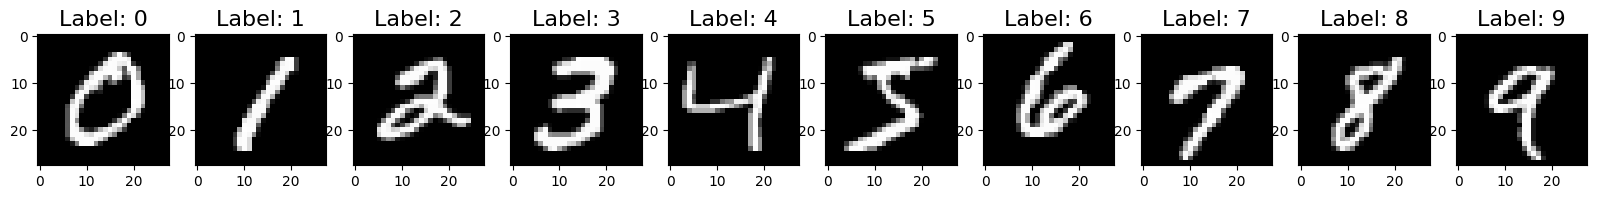

In [87]:
num_classes = 10
f, ax = plt.subplots(1, num_classes, figsize=(20,20))
for i in range(0, num_classes):
    sample = x_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title("Label: {}".format(i), fontsize=(16))

In [88]:
for i in range(10):
    print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [89]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

#PREPARE DATA

In [90]:
#Normalize daat
x_train = x_train / 255
x_test = x_test / 255

In [91]:
#Reshape data
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape)

(60000, 784)


# Create Model - fully Connected NN

In [92]:
model = Sequential()

In [93]:
model.add(Dense(units=128, input_shape=(784,), activation="relu"))
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(units=10, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape        ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ dense_14 (Dense)            │ (None, 128)         │     100,480 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_15 (Dense)            │ (None, 128)         │      16,512 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_5 (Dropout)         │ (None, 128)         │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_16 (Dense)            │ (None, 10)          │       1,290 │
└─────────────────────────────┴─────────────────────┴─────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
batch_size = 512
epochs= 10
model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=epochs)


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8267 - loss: 0.6023
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9335 - loss: 0.2297
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9518 - loss: 0.1679
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9609 - loss: 0.1337
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9667 - loss: 0.1131
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9712 - loss: 0.0967
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9745 - loss: 0.0835
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9780 - loss: 0.0733
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.0643
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9828 - loss: 0.0564


# EVALUATE

In [95]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Loss: {}, Test Accuracy: {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9773 - loss: 0.0709
Test Loss: 0.0709477886557579, Test Accuracy: 0.9772999882698059


In [96]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1.2108871e-05 1.9824315e-06 2.4521809e-05 ... 9.9981219e-01
  1.0851242e-06 1.6836708e-05]
 [6.1981540e-09 1.6222056e-04 9.9981230e-01 ... 3.8660315e-09
  5.9498911e-06 5.1943194e-10]
 [1.4441102e-05 9.9737263e-01 4.6512517e-04 ... 1.2309767e-03
  4.7250229e-04 2.0060885e-05]
 ...
 [7.7543233e-10 8.1455225e-09 6.2812605e-10 ... 8.2817292e-07
  1.9751780e-05 1.2260622e-04]
 [5.9175342e-08 4.8840523e-09 2.1925259e-10 ... 3.4297727e-07
  2.2737499e-04 9.2950120e-10]
 [1.1765538e-08 3.7121858e-11 1.1912284e-09 ... 1.6975658e-12
  1.3198471e-10 2.8418834e-13]]
[7 2 1 ... 4 5 6]


In [97]:
#sinle example

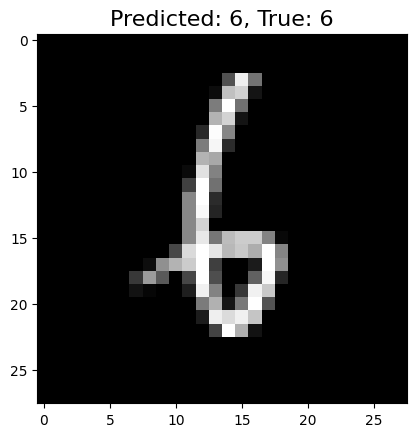

In [98]:
random_idx = np.random.choice(len(x_test))
x_sample = x_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title("Predicted: {}, True: {}".format(y_sample_pred_class, y_sample_true), fontsize=16)
plt.imshow(x_sample.reshape(28,28), cmap="gray")

# Confusion matrix

Text(0.5, 1.0, 'Confusion matrix')

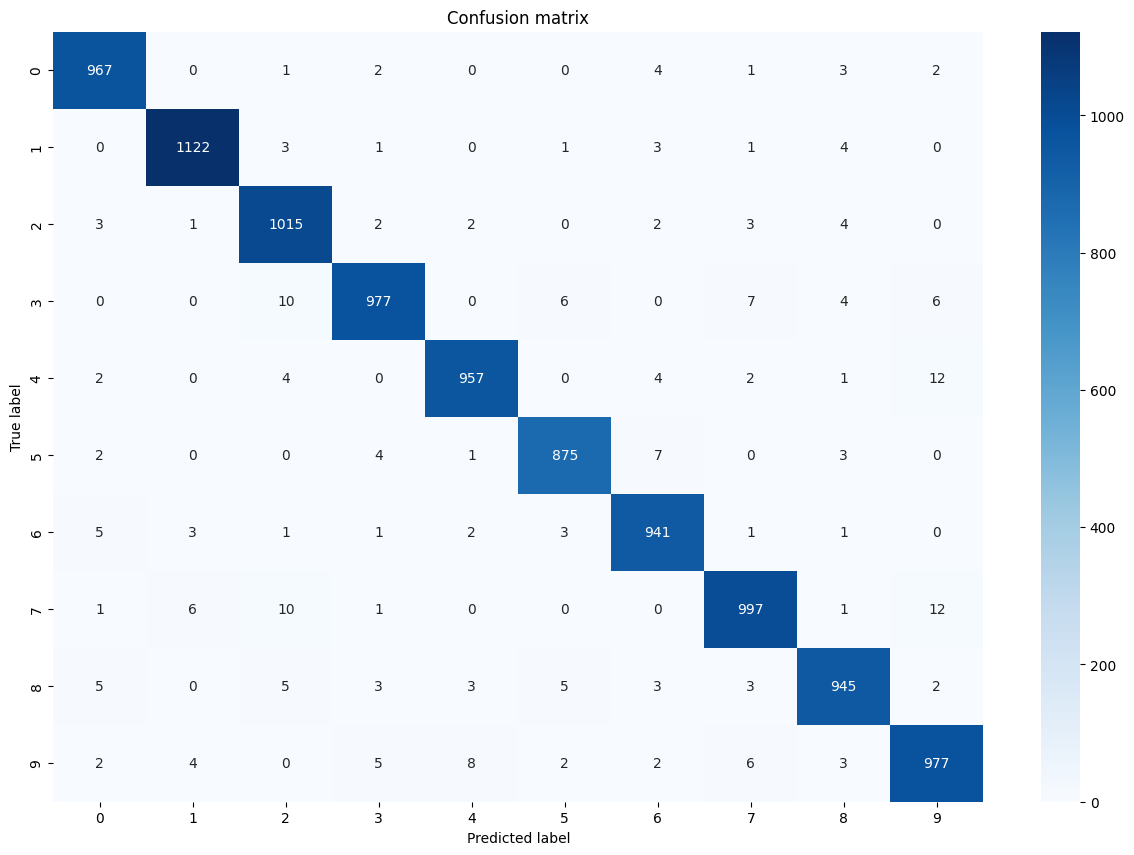

In [99]:
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

#plot
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d', ax=ax, cmap="Blues")
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix')